<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Hito3_CNN%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [30]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from torchvision import datasets, models, transforms
import time


seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


# Cargar datos y descargar imagenes utilizadas

In [2]:
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
dfdata = pd.read_csv(url)
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
df_descriptions = pd.read_csv(url)

In [3]:
def class_owners(strowners):
  own_int = int(strowners.split('-')[0])
  if own_int > 100000:
    return 'Hsell'
  else:
    return 'Lsell'
class_owners(dfdata.owners[100])

'Lsell'

<Axes: xlabel='owners_label'>

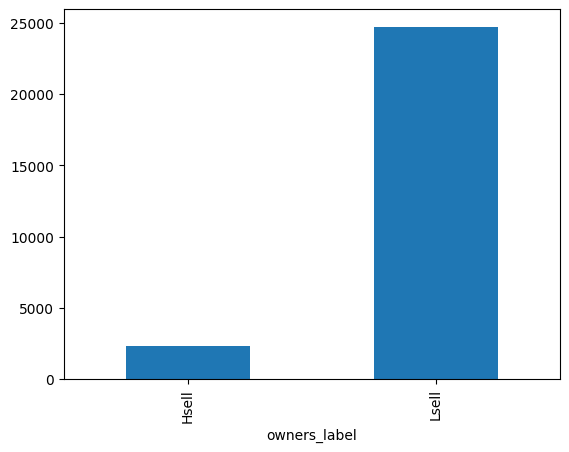

In [4]:
dfdata['owners_label'] = [ class_owners(i) for i in dfdata.owners ]
dfdata.groupby('owners_label').count().loc[:,'name'].plot.bar()

Seleccionamos un sample de 500 por cada clase

In [5]:
Nsample = 600
labels = ['Hsell','Lsell']
list_ids = [ random.sample(list(dfdata.index[dfdata.owners_label.isin([i])]),k=Nsample) for i in labels ]
dfsample = dfdata.loc[ sum(list_ids,[]) , ['appid','name','genres','owners','owners_label'] ]
dfsample

,appid,name,genres,owners,owners_label
5923,377310,The Tower Of Elements,Action;Indie,200000-500000,Hsell
174,6870,Battlestations: Midway,Action,200000-500000,Hsell
1888,246900,Viscera Cleanup Detail,Indie;Simulation,500000-1000000,Hsell
14401,626690,Sword Art Online: Fatal Bullet,Action;RPG,200000-500000,Hsell
2775,285190,"Warhammer 40,000: Dawn of War III",Violent;Gore;Action;Simulation;Strategy,500000-1000000,Hsell
...,...,...,...,...,...
10044,502780,Avalon: The Journey Begins,Adventure;Indie,0-20000,Lsell
19784,784000,Let's be architects,Casual;Indie;Strategy,0-20000,Lsell
13505,598230,Ascender,Adventure;Indie,0-20000,Lsell
17241,710970,Learn (Japanese) Kana The Fun Way!,Casual;Indie,0-20000,Lsell


In [ ]:
list_img = []

for i in dfsample.appid:
  !wget https://cdn.cloudflare.steamstatic.com/steam/apps/{i}/header.jpg
  list_img.append(Image.open('header.jpg'))
  !rm header.jpg




# 1 Definicion de clases y transformaciones


In [18]:
class GamesDataset(torch.utils.data.Dataset):
  def __init__(self, dataX, dataY, transform):
    self.transform = transform
    self.class2idx = dict()
    self.class2idx['Lsell'] = 0
    self.class2idx['Hsell'] = 1

    self.classes = ['Lsell','Hsell']

    self.images = dataX
    self.labels = dataY

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    #image = Image.open(image_path)
    label = self.class2idx[self.labels[idx]]
    im = self.images[idx].convert('RGB')

    if self.transform:
      image = self.transform(im)

    return image, label

In [21]:
transforms = transforms.Compose([transforms.Resize(256),
                    transforms.CenterCrop(224),
                    transforms. ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

Split dataset en train, validation y test

In [12]:
from sklearn.model_selection import train_test_split
ylabel = list(dfsample['owners_label'])
X_train, X_test, Y_train, Y_test = train_test_split(list_img, ylabel, test_size = 0.2, stratify = ylabel , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/80, stratify= Y_train, random_state=seed)

Lsell


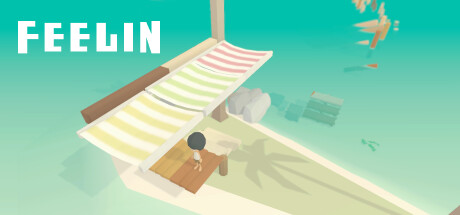

In [16]:
print(Y_train[33])
X_train[33]

# 1. Preprocesamiento de los datos

- Eliminacion de puntuaciones en strings

In [29]:
# crear Games datasets
train_data = GamesDataset(dataX = X_train, dataY = Y_train , transform = transforms)
valid_data = GamesDataset(dataX = X_val, dataY = Y_val , transform = transforms)
test_data  = GamesDataset(dataX = X_val, dataY = Y_val , transform = transforms)
# dataloaders
batch_size = 20

train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size)
test_loader  = DataLoader(test_data, shuffle=False, batch_size=1)

In [ ]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()

if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')